# Generate data from rate model

firing rates, LFP, behavior

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

import sys

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld

import pickle as pk

2026-03-03 22:47:49.576953: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 22:47:49.607093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-03 22:47:49.639550: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-03 22:47:49.646785: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-03 22:47:49.675991: I tensorflow/core/platform/cpu_feature_guar

### check trained models

In [2]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/'

model_names = ld.find_files(model_dir, '*.mat')
print(len(model_names))
print(model_names)

36
['/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_03_03_044731.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_084724.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_03_03_140155.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_14_213742.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_03_02_153155.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_13_185831.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_03_02_202011.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_03_03_062847.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_03_02_172631.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_002559.ma

In [8]:
# move models that did not train properly to new folder
import os

new_dir = os.path.join(model_dir, 'incomplete_training')

if not os.path.exists(new_dir):
    os.makedirs(new_dir)

for i, model_name in enumerate(model_names):
    model_path = os.path.join(model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    tr_trials = model_data['tr'][0][0]
    if tr_trials == 39999:
        model_name_nopath = os.path.basename(model_name)
        print(f'moving {model_name_nopath} with {tr_trials} trials')
        os.rename(model_path, os.path.join(new_dir, model_name_nopath))
        

moving Task_sternberg_N_400_Jitter_5_3_2026_02_14_225831.mat with 39999 trials
moving Task_sternberg_N_400_Jitter_5_3_2026_02_16_091509.mat with 39999 trials
moving Task_sternberg_N_400_Jitter_5_3_2026_02_15_180201.mat with 39999 trials
moving Task_sternberg_N_400_Jitter_5_3_2026_02_16_010941.mat with 39999 trials
moving Task_sternberg_N_400_Jitter_5_3_2026_02_13_200127.mat with 39999 trials
moving Task_sternberg_N_400_Jitter_5_3_2026_02_14_230041.mat with 39999 trials
moving Task_sternberg_N_400_Jitter_5_3_2026_02_15_212259.mat with 39999 trials
moving Task_sternberg_N_400_Jitter_5_3_2026_02_15_192700.mat with 39999 trials
moving Task_sternberg_N_400_Jitter_5_3_2026_02_16_081718.mat with 39999 trials


In [9]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/'

model_names = ld.find_files(model_dir, '*.mat')
print(len(model_names))
print(model_names)

13
['/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_084724.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_14_213742.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_13_185831.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_002559.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_14_213423.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_16_062747.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_205451.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_044336.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_022733.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_14_225313.ma

In [10]:
model_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'x0', 'r0', 'w0', 'taus_gaus0', 'w_in0', 'u', 'o', 'w', 'x', 'target', 'w_out', 'r', 'm', 'som_m', 'N', 'exc', 'inh', 'w_in', 'b_out', 'som_N', 'losses', 'taus', 'eval_perf_mean', 'eval_loss_mean', 'eval_os', 'eval_labels', 'taus_gaus', 'tr', 'activation', 'stim_on_tr', 'stim_dur_tr', 'p_low', 'eval_perfs', 'load', 'delay_tr', 'T_tr'])

In [3]:
perfs = []
train_trials = []
for i, model_path in enumerate(model_names):
    # model_path = os.path.join(model_dir, model_name)
    model_name = os.path.basename(model_path)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perfs'][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')


Model: Task_sternberg_N_400_Jitter_5_3_2026_03_03_044731.mat, Test perf: [0.96 0.94], Train trials: 16001
Model: Task_sternberg_N_400_Jitter_5_3_2026_02_15_084724.mat, Test perf: [0.97 0.81], Train trials: 22501
Model: Task_sternberg_N_400_Jitter_5_3_2026_03_03_140155.mat, Test perf: [0.98 0.94], Train trials: 33901
Model: Task_sternberg_N_400_Jitter_5_3_2026_02_14_213742.mat, Test perf: [0.96 0.86], Train trials: 28701
Model: Task_sternberg_N_400_Jitter_5_3_2026_03_02_153155.mat, Test perf: [0.96 0.93], Train trials: 29801
Model: Task_sternberg_N_400_Jitter_5_3_2026_02_13_185831.mat, Test perf: [0.96 0.93], Train trials: 26601
Model: Task_sternberg_N_400_Jitter_5_3_2026_03_02_202011.mat, Test perf: [0.96 1.  ], Train trials: 37701
Model: Task_sternberg_N_400_Jitter_5_3_2026_03_03_062847.mat, Test perf: [0.96 0.84], Train trials: 22201
Model: Task_sternberg_N_400_Jitter_5_3_2026_03_02_172631.mat, Test perf: [0.97 0.95], Train trials: 24301
Model: Task_sternberg_N_400_Jitter_5_3_2026_02

### generate data for longer delay (200)

In [4]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model

Instructions for updating:
non-resource variables are not supported in the long term


In [5]:
def generate_input_stim_sternberg_type(settings, match=0):
    # match = 0 for mismatch, 1 for match

    T = settings['T']
    stim_on = settings['stim_on']
    stim_dur = settings['stim_dur']
    delay = settings['delay']
    load = settings['load'] # int for number of items to remember
    
    n_channels = 4

    # Initialize u
    u = np.zeros((n_channels, T))
    
    # Sternberg task
    stim_chan_idx = np.random.choice(n_channels, load, replace=False)
    for i, i_chan in enumerate(stim_chan_idx):
        if i == 0:
            u[i_chan, stim_on:stim_on+stim_dur] = 1
            ending_idx = stim_on+stim_dur
        else: # 0 bc no separation btwn stimuli
            u[i_chan, ending_idx+0:ending_idx+stim_dur+0] = 1
            ending_idx = ending_idx+stim_dur+0
    
    if match == 1:
        # match, so pick a chan from activated chans
        match_chan_idx = np.random.choice(stim_chan_idx, 1)[0]
        u[match_chan_idx, ending_idx+delay:ending_idx+delay+stim_dur] = 1
        label = 1
    elif match == 0:
        # mismatch, so pick a chan from non-activated chans
        non_stim_chan_idx = np.setdiff1d(np.arange(n_channels), stim_chan_idx) # the non-activated channel
        non_match_chan_idx = np.random.choice(non_stim_chan_idx, 1)[0]
        u[non_match_chan_idx, ending_idx+delay:ending_idx+delay+stim_dur] = 1
        label = -1
    else:
        raise ValueError('match must be 0 or 1')

    return u, label

In [ ]:
# conceptually what's happening (don't run, not parallelized):

n_trials = 50
eval_amp_threshold = 0.7
matches = [0, 1] # 0 for mismatch, 1 for match
loads = [1, 3] # number of items to remember
model_list = model_names

# delay200
settings = {
        'T': 450, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 25, # input stim duration (in steps)
        'delay': 200, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'fs': 200,
        'task': 'sternberg', # task name
        'load': 1,
        }

for n_model, model_path in enumerate(model_list):
    model_name = os.path.basename(model_path)
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')) and os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for load in loads:
        settings['load'] = load
        resp_onset = settings['stim_on'] + load*settings['stim_dur'] + settings['delay'] + 10
        for match in matches:
            for n in range(n_trials):
                u, label = generate_input_sternberg_type(settings, match=match)
                trial_type = [load, match]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', 
                                              settings=settings, u=u, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 1:
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed


def run_single_model(model_path,
                     model_dir,
                     settings,
                     n_trials,
                     loads,
                     matches,
                     eval_amp_threshold):

    model_name = os.path.basename(model_path)
    output_dir = os.path.join(model_dir, model_name[:-4])
    os.makedirs(output_dir, exist_ok=True)

    # Skip if already computed
    neural_path = os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')
    bhv_path = os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')
    settings_path = os.path.join(output_dir, f'settings_dict_delay{settings["delay"]}.pkl')

    if os.path.exists(neural_path) and os.path.exists(bhv_path):
        print(f'skipping {model_name}, already saved')
        return

    neural_dict = {'r': [], 'epsp': []}
    bhv_dict = {'perf': [], 'trial_type': [], 'outputs': []}

    for load in loads:
        local_settings = settings.copy()  # avoid shared-state issues
        local_settings['load'] = load

        resp_onset = (
            local_settings['stim_on']
            + load * local_settings['stim_dur']
            + local_settings['delay']
            + 10
        )

        for match in matches:
            for _ in range(n_trials):

                u, label = generate_input_stim_sternberg_type(local_settings, match=match)

                _, r, o, epsp = model.eval_tf(
                    model_dir=f'{model_dir}/{model_name}',
                    settings=local_settings,
                    u=u,
                    calc_epsp=True
                )

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)

                # Behavioral performance
                if label == 1:
                    perf = int(np.max(o[resp_onset:]) > eval_amp_threshold)
                else:
                    perf = int(np.min(o[resp_onset:]) < -eval_amp_threshold)

                bhv_dict['perf'].append(perf)
                bhv_dict['trial_type'].append([load, match])
                bhv_dict['outputs'].append(o)
                
    # Convert to arrays
    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    bhv_dict['outputs'] = np.array(bhv_dict['outputs'])

    # Save results
    with open(neural_path, 'wb') as f:
        pk.dump(neural_dict, f)

    with open(bhv_path, 'wb') as f:
        pk.dump(bhv_dict, f)
        
    with open(settings_path, 'wb') as f:
        pk.dump(local_settings, f)

    print(f"✔ Saved model outputs to {output_dir}")


if __name__ == "__main__":

    n_trials = 50
    eval_amp_threshold = 0.7
    matches = [0, 1]
    loads = [1, 3]
    model_list = model_names

    settings = {
        'T': 450,
        'stim_on': 50,
        'stim_dur': 25,
        'delay': 200,
        'DeltaT': 1,
        'taus': 20,
        'fs': 200,
        'task': 'sternberg',
        'load': 1,
    }

    # Adjust max_workers to your CPU count
    with ProcessPoolExecutor() as executor:

        futures = [
            executor.submit(
                run_single_model,
                model_path,
                model_dir,
                settings,
                n_trials,
                loads,
                matches,
                eval_amp_threshold
            )
            for model_path in model_list
        ]

        for future in as_completed(futures):
            future.result()  # raises exceptions if any

skipping Task_sternberg_N_400_Jitter_5_3_2026_02_15_084724.mat, already savedskipping Task_sternberg_N_400_Jitter_5_3_2026_02_13_185831.mat, already savedskipping Task_sternberg_N_400_Jitter_5_3_2026_02_14_213742.mat, already saved
skipping Task_sternberg_N_400_Jitter_5_3_2026_02_15_002559.mat, already saved
skipping Task_sternberg_N_400_Jitter_5_3_2026_02_14_213423.mat, already savedskipping Task_sternberg_N_400_Jitter_5_3_2026_02_16_062747.mat, already saved
skipping Task_sternberg_N_400_Jitter_5_3_2026_02_15_205451.mat, already savedskipping Task_sternberg_N_400_Jitter_5_3_2026_02_15_044336.mat, already saved



skipping Task_sternberg_N_400_Jitter_5_3_2026_02_14_225313.mat, already saved

skipping Task_sternberg_N_400_Jitter_5_3_2026_02_15_022733.mat, already savedskipping Task_sternberg_N_400_Jitter_5_3_2026_02_15_073111.mat, already saved
skipping Task_sternberg_N_400_Jitter_5_3_2026_02_15_010846.mat, already savedskipping Task_sternberg_N_400_Jitter_5_3_2026_02_16_061458.mat, al

### make some quick behavior plots

In [4]:
colors = ['#49BEA3', '#6E439A']

No data for Task_sternberg_N_400_Jitter_5_3_2026_03_03_191124.mat, skipping


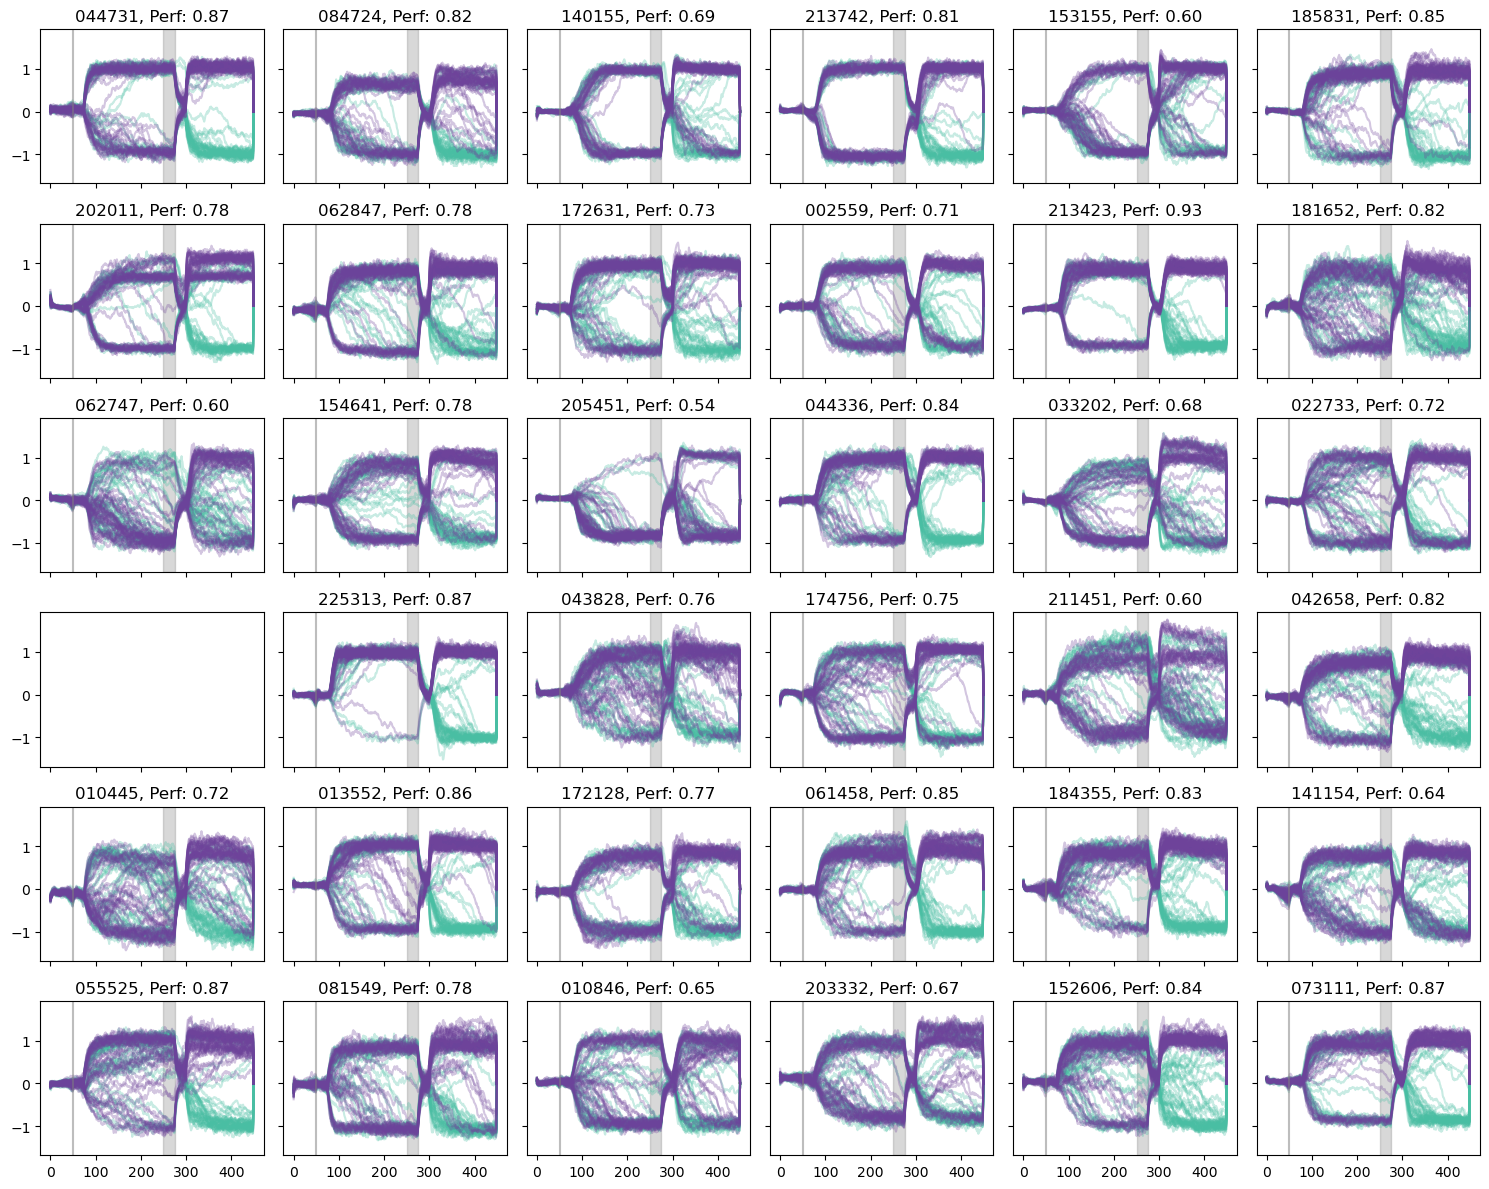

No data for Task_sternberg_N_400_Jitter_5_3_2026_03_03_191124.mat, skipping


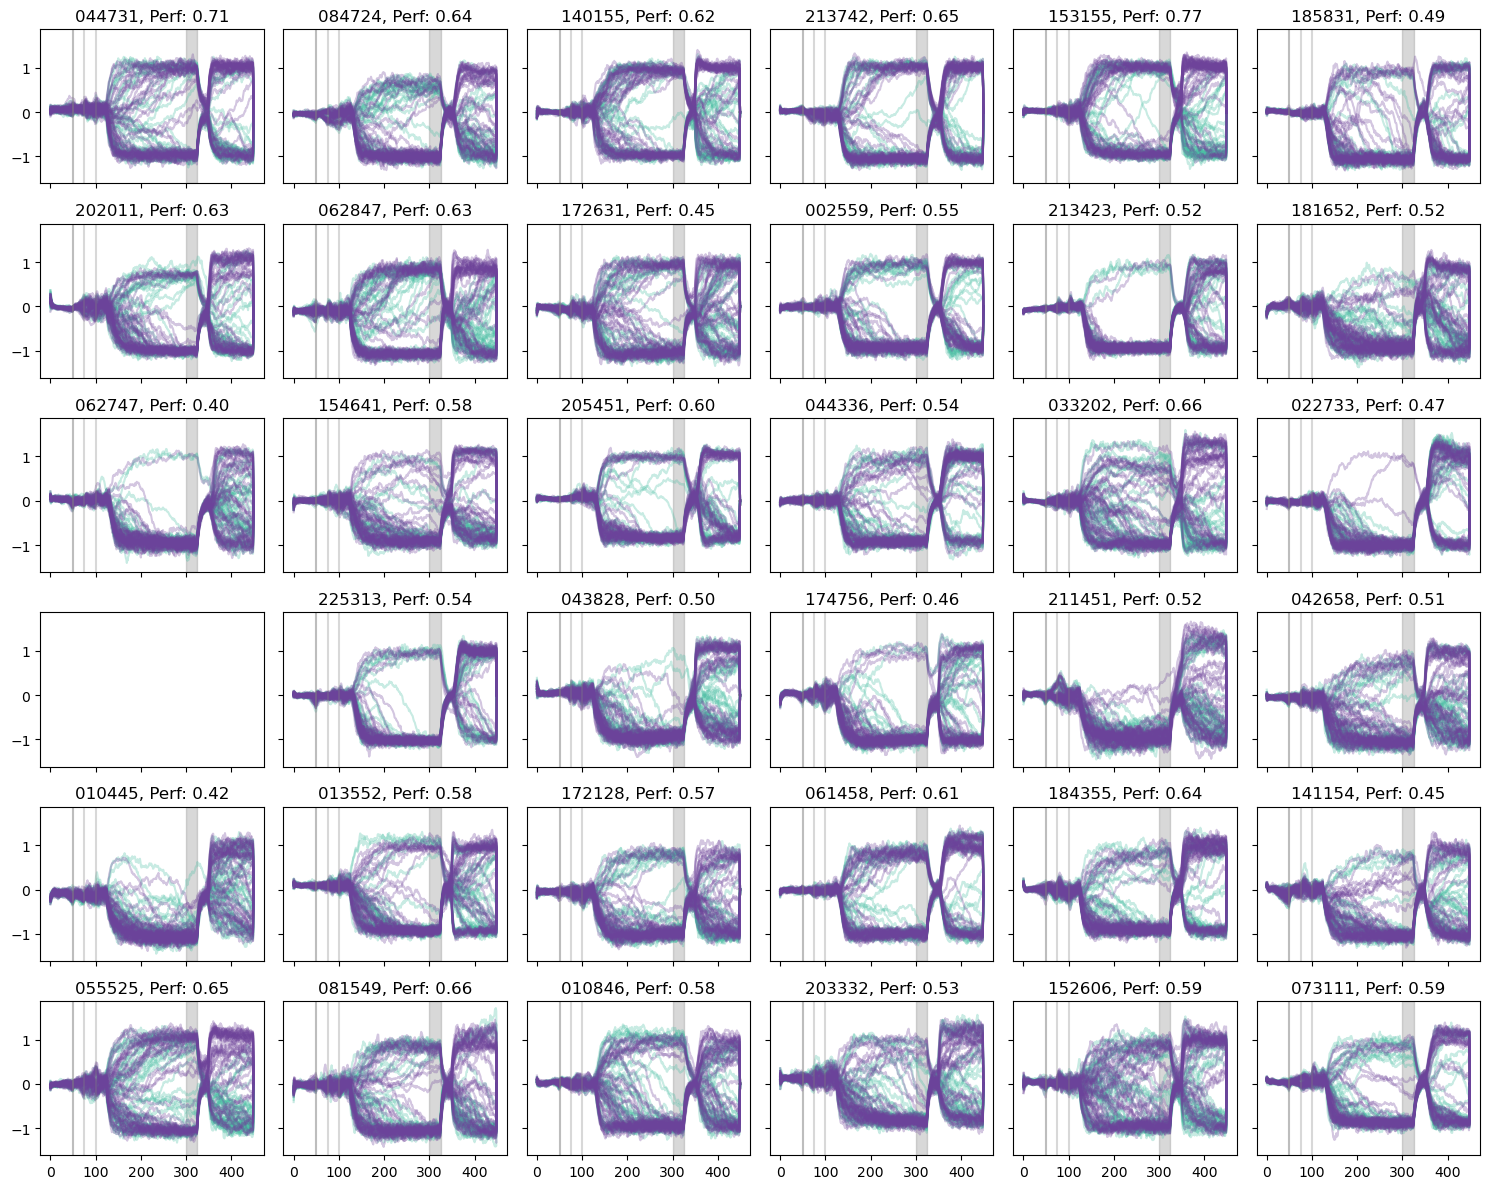

In [7]:
# plot output for each model

settings = {
        'T': 450,
        'stim_on': 50,
        'stim_dur': 25,
        'delay': 200,
        'DeltaT': 1,
        'taus': 20,
        'fs': 200,
        'task': 'sternberg',
        'load': 1,
    }


for k, load in enumerate([1, 3]):
    fig, axs = plt.subplots(6,6, figsize=(15,12), sharex=True, sharey=True)
    axs = axs.flatten()
    test_perfs = []
    for i, model_path in enumerate(model_names):
        model_name = os.path.basename(model_path)
        output_dir = model_dir + model_name[:-4] + '/'
        try:
            with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
                bhv_dict = pk.load(f)
            with open(os.path.join(output_dir, f'settings_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
                settings = pk.load(f)
        except:
            print(f'No data for {model_name}, skipping')
            continue
        
        this_load_idx = np.where(np.array(bhv_dict['trial_type'])[:,0] == load)[0]
        for n in this_load_idx:
             axs[i].plot(bhv_dict['outputs'][n], color=colors[int(bhv_dict['trial_type'][n][1] == 1)], alpha=0.3)
        
        axs[i].set_title(f'{model_name[-10:-4]}, Perf: {np.mean(bhv_dict["perf"][this_load_idx]):.2f}')
        test_perfs.append(np.mean(bhv_dict['perf']))
        stim1_on = settings['stim_on']
        axs[i].axvline(stim1_on, color='gray', alpha=0.3)
        for n in range(load):
            stim_on = settings['stim_on'] + n*settings['stim_dur']
            axs[i].axvline(stim_on, color='gray', alpha=0.3)
        axs[i].axvspan(stim_on + settings['delay'], stim_on + settings['delay'] + settings['stim_dur'], color='gray', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [7]:
test_perfs = []
loads = [1, 3]
for i, model_path in enumerate(model_names):
    model_name = os.path.basename(model_path)
    output_dir = model_dir + model_name[:-4] + '/'
    
    with open(os.path.join(output_dir, f'settings_dict_delay{200}.pkl'), 'rb') as f:
        settings = pk.load(f)
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)
    
    load_perfs = np.zeros(2)
    for n, load in enumerate(loads):
        this_load_idx = np.where(np.array(bhv_dict['trial_type'])[:,0] == load)[0]
        load_perfs[n] = np.mean(bhv_dict['perf'][this_load_idx])
    test_perfs.append(load_perfs)
    
test_perfs = np.array(test_perfs)
test_perfs

array([[0.82, 0.64],
       [0.81, 0.65],
       [0.85, 0.49],
       [0.71, 0.55],
       [0.93, 0.52],
       [0.6 , 0.4 ],
       [0.54, 0.6 ],
       [0.84, 0.54],
       [0.72, 0.47],
       [0.87, 0.54],
       [0.85, 0.61],
       [0.65, 0.58],
       [0.87, 0.59]])

/tmp/ipykernel_920710/2922517119.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot([perfs[:,i], test_perfs[:,i]], labels=['Delay=10', 'Delay=200'])
/tmp/ipykernel_920710/2922517119.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot([perfs[:,i], test_perfs[:,i]], labels=['Delay=10', 'Delay=200'])
/tmp/ipykernel_920710/2922517119.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[2].boxplot([perfs[:,0], perfs[:,1]], labels=['Load 1', 'Load 3'])
/tmp/ipykernel_920710/2922517119.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' si

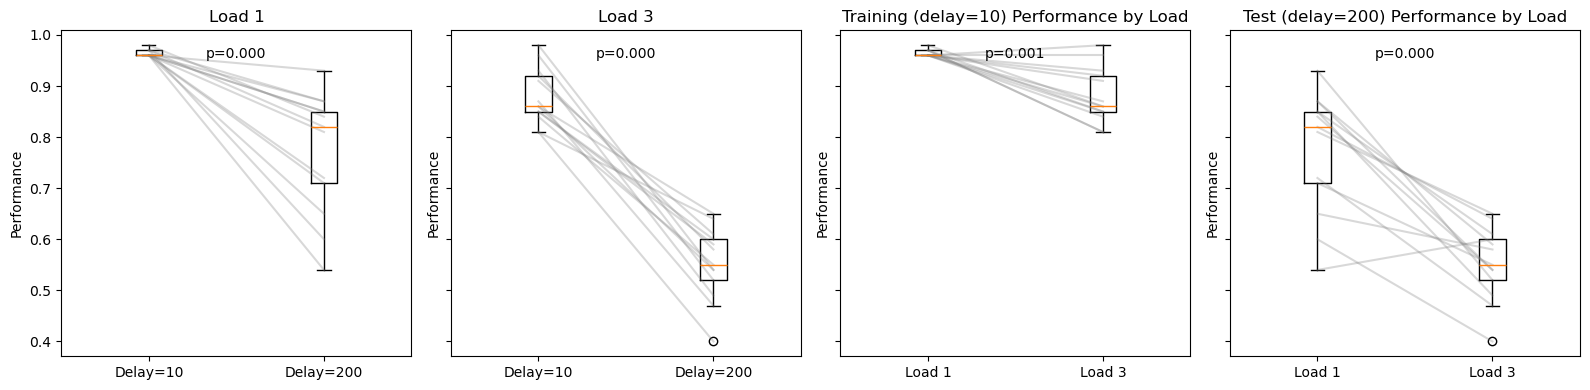

In [13]:
# plot behavior boxplots
perfs = np.array(perfs)
test_perfs = np.array(test_perfs)

fig, axs = plt.subplots(1, 4, figsize=(16,4), sharey=True)

# first compare Training and Test performance for each load
for i, load in enumerate(loads):
    axs[i].boxplot([perfs[:,i], test_perfs[:,i]], labels=['Delay=10', 'Delay=200'])
    axs[i].set_title(f'Load {load}')
    axs[i].set_ylabel('Performance')
    
    # include stats
    from scipy.stats import wilcoxon
    stat, p = wilcoxon(perfs[:,i], test_perfs[:,i])
    axs[i].text(0.5, 0.95, f'p={p:.3f}', transform=axs[i].transAxes, ha='center', va='top')
    
    # gray lines for individual models
    for j in range(perfs.shape[0]):
        axs[i].plot([1, 2], [perfs[j,i], test_perfs[j,i]], color='gray', alpha=0.3)

# next compare training performance across loads
axs[2].boxplot([perfs[:,0], perfs[:,1]], labels=['Load 1', 'Load 3'])
axs[2].set_title('Training (delay=10) Performance by Load')
axs[2].set_ylabel('Performance')
stat, p = wilcoxon(perfs[:,0], perfs[:,1])
axs[2].text(0.5, 0.95, f'p={p:.3f}', transform=axs[2].transAxes, ha='center', va='top')
for j in range(perfs.shape[0]):
    axs[2].plot([1, 2], [perfs[j,0], perfs[j,1]], color='gray', alpha=0.3)

# next compare test performance across loads
axs[3].boxplot([test_perfs[:,0], test_perfs[:,1]], labels=['Load 1', 'Load 3'])
axs[3].set_title('Test (delay=200) Performance by Load')
axs[3].set_ylabel('Performance')
stat, p = wilcoxon(test_perfs[:,0], test_perfs[:,1])
axs[3].text(0.5, 0.95, f'p={p:.3f}', transform=axs[3].transAxes, ha='center', va='top')
for j in range(test_perfs.shape[0]):
    axs[3].plot([1, 2], [test_perfs[j,0], test_perfs[j,1]], color='gray', alpha=0.3)

plt.tight_layout()
plt.show()
    

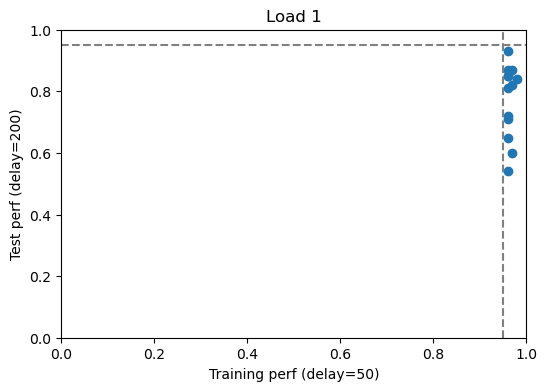

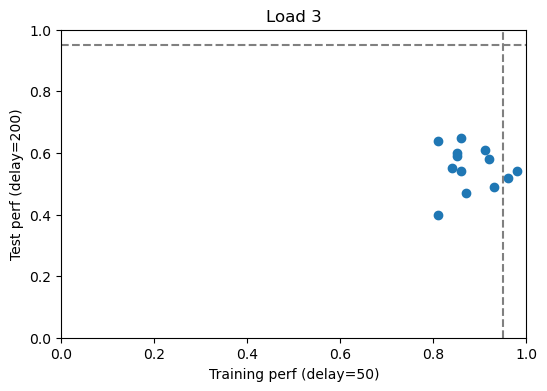

In [52]:
# plot behavior 
perfs = np.array(perfs)
test_perfs = np.array(test_perfs)

for i, load in enumerate(loads):
    plt.figure(figsize=(6,4))
    plt.scatter(perfs[:,i], test_perfs[:,i])
    plt.axvline(x=0.95, color='gray', linestyle='--')
    plt.axhline(y=0.95, color='gray', linestyle='--')
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.xlabel('Training perf (delay=50)')
    plt.ylabel('Test perf (delay=200)')
    plt.title(f'Load {load}')
    plt.show()


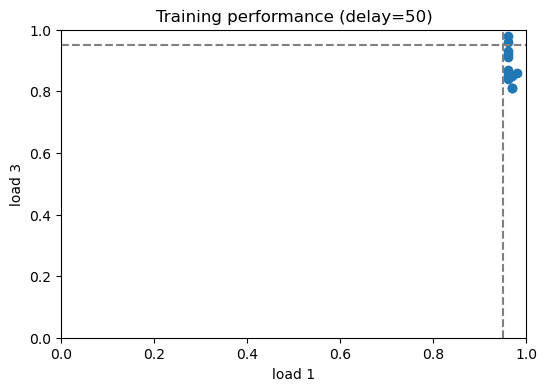

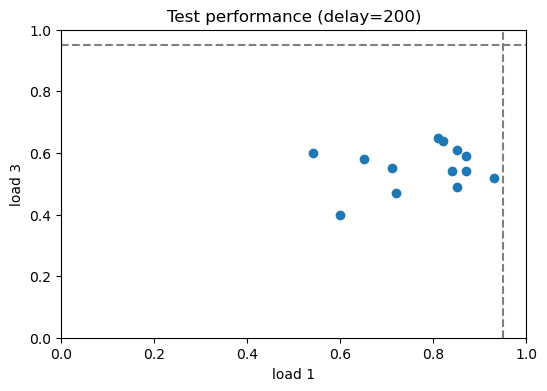

In [54]:
# plot behavior 

plt.figure(figsize=(6,4))
plt.scatter(perfs[:,0], perfs[:,1])
plt.axvline(x=0.95, color='gray', linestyle='--')
plt.axhline(y=0.95, color='gray', linestyle='--')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('load 1')
plt.ylabel('load 3')
plt.title('Training performance (delay=50)')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(test_perfs[:,0], test_perfs[:,1])
plt.axvline(x=0.95, color='gray', linestyle='--')
plt.axhline(y=0.95, color='gray', linestyle='--')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('load 1')
plt.ylabel('load 3')
plt.title('Test performance (delay=200)')
plt.show()